# Parameter estimation via Differential Evolution in jump-diffusion models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdospina/jump-diffusion-estimation/blob/main/notebooks/differential_evolution_showcase_en.ipynb)

This notebook illustrates **Differential Evolution (global optimization)** versus the classic **L-BFGS-B (local optimization)** for parameter estimation in jump-diffusion models.

## The problem: non-convex, multimodal likelihoods

In jump-diffusion models (such as Merton's, or asymmetric extensions like Kou and SGED) the likelihood is built as an (approximate) mixture of probability densities.

With a flexible, heavy-tailed jump distribution such as the **Skewed Generalized Error Distribution (SGED)**, the resulting log-likelihood surface has:
1. Multiple local optima (multimodality).
2. Flat regions or narrow ridges where gradients are nearly zero.
3. High sensitivity to the starting values.

As shown in the thesis of *Ospina Arango (2009)*, local gradient-based optimizers like **L-BFGS-B** often stall at poor local optima or at the parameter boundaries, whereas **Differential Evolution (DE)** -- a stochastic, derivative-free global search -- recovers the true parameters accurately without requiring a precise initial guess.

> Hay una versión en español de este notebook: `differential_evolution_showcase.ipynb`.

## 1. Environment setup and imports

First we import the libraries needed for simulation, estimation, statistical analysis and plotting.

In [1]:
%pip install -q jump-diffusion-estimation ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from jump_diffusion import JumpDiffusionSimulator, JumpDiffusionEstimator
from jump_diffusion.distributions import SGEDJump

# Visual style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 2. Simulate synthetic data with known parameters

We define a set of true parameters and simulate a daily path over 3 years ($T = 3.0$ years, $n\_steps = 756$ daily observations). We use the **SGED** distribution for the jump size, with substantial positive skewness ($\xi = 1.8$) and heavy tails ($\nu = 1.3$).

In [3]:
# True model parameters
true_params = {
    "mu": 0.12,          # 12% annual drift
    "sigma": 0.25,       # 25% diffusion volatility
    "jump_prob": 0.08,   # 8% daily jump probability
}

# Jump-specific parameters (SGED)
true_jump_params = {
    "jump_loc": 0.0,     # centered at zero
    "jump_scale": 0.15,  # jump-size scale
    "jump_nu": 1.3,      # tail shape (< 2.0 means heavier tails than normal)
    "jump_xi": 1.8,      # positive skewness (> 1.0 means positive skew)
}

# Instantiate the simulator
simulator = JumpDiffusionSimulator(
    jump_distribution=SGEDJump(),
    **true_params,
    **true_jump_params
)

# Simulate the path
T = 3.0
n_steps = 756
times, path, jumps = simulator.simulate_path(T=T, n_steps=n_steps, x0=100.0, seed=42)
increments = np.diff(path)
dt = T / n_steps

print(f"Simulated {len(path)} path points with {np.sum(jumps != 0)} realized jumps.")

Simulated 757 path points with 72 realized jumps.


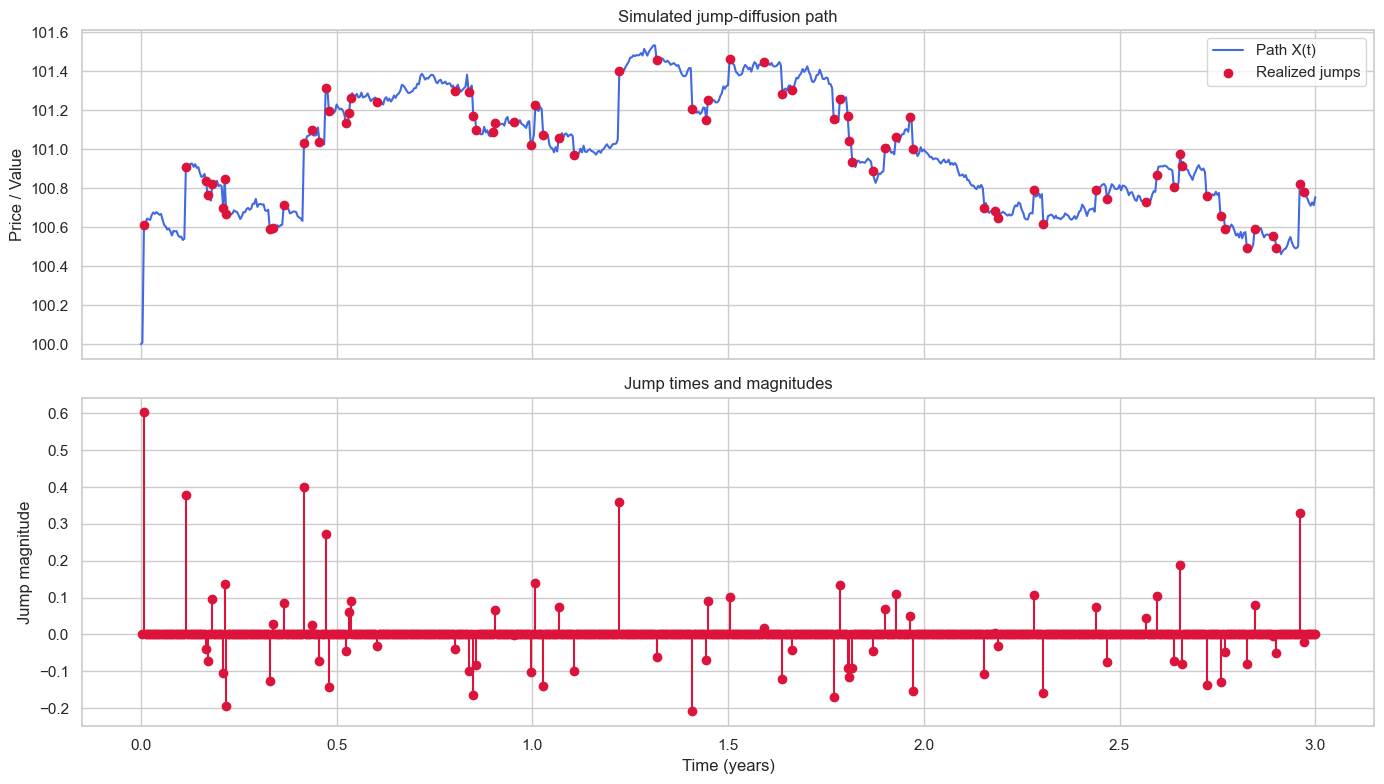

In [4]:
# Plot the simulated path and its components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(times, path, color="royalblue", label="Path X(t)")
jump_times = times[1:][jumps != 0]
jump_vals = path[1:][jumps != 0]
ax1.scatter(jump_times, jump_vals, color="crimson", zorder=5, label="Realized jumps")
ax1.set_title("Simulated jump-diffusion path")
ax1.set_ylabel("Price / Value")
ax1.legend()

ax2.stem(times[1:], jumps, linefmt="crimson", markerfmt="o", basefmt=" ", label="Jump magnitude")
ax2.set_ylabel("Jump magnitude")
ax2.set_xlabel("Time (years)")
ax2.set_title("Jump times and magnitudes")
plt.tight_layout()
plt.show()

## 3. Estimation via local optimization (L-BFGS-B)

We first estimate the parameters with `L-BFGS-B`. This algorithm needs an initial guess; by default the library computes a moment-based guess (means, variances and skewness of the increments) to provide a good starting point.

In [5]:
estimator_lbfgsb = JumpDiffusionEstimator(increments, dt, jump_distribution=SGEDJump())

t_start = time.time()
results_lbfgsb = estimator_lbfgsb.estimate(method="L-BFGS-B")
t_lbfgsb = time.time() - t_start

print(f"L-BFGS-B run time: {t_lbfgsb:.4f} seconds.")
estimator_lbfgsb.diagnostics()

L-BFGS-B run time: 1.6111 seconds.
JUMP-DIFFUSION ESTIMATION RESULTS
Drift (μ):              0.251728
Volatility (σ):         0.768392
Jump probability (p):   0.100000
jump_loc                -0.000000
jump_scale              0.024202
jump_nu                 2.000000
jump_xi                 1.300000

Log-likelihood:         1263.82
AIC:                    -2513.64
BIC:                    -2481.24
Convergence:            False

DATA vs MODEL COMPARISON
------------------------------
Mean increment:
  Empirical:  0.000999
  Theoretical: 0.000999
Std deviation:
  Empirical:  0.048404
  Theoretical: 0.049005
Expected jumps: 75.6


## 4. Estimation via global optimization (Differential Evolution)

Now we run the estimator configured to use `differential_evolution`. This algorithm needs no initial guess (it samples a uniform population inside a bounded, data-driven adaptive search box). The computational cost is markedly higher (thousands of mixture-likelihood evaluations), but it is far more immune to local optima.

In [6]:
estimator_de = JumpDiffusionEstimator(increments, dt, jump_distribution=SGEDJump())

t_start = time.time()
# Fixed seed (seed=42) for reproducibility
results_de = estimator_de.estimate(method="differential_evolution", seed=42)
t_de = time.time() - t_start

print(f"Differential Evolution run time: {t_de:.4f} seconds (evaluating ~4000-8000 candidates).")
estimator_de.diagnostics()

Differential Evolution run time: 9.1540 seconds (evaluating ~4000-8000 candidates).
JUMP-DIFFUSION ESTIMATION RESULTS
Drift (μ):              -0.043463
Volatility (σ):         0.243996
Jump probability (p):   0.096823
jump_loc                0.010452
jump_scale              0.148939
jump_nu                 1.743389
jump_xi                 15.647106

Log-likelihood:         1760.59
AIC:                    -3507.19
BIC:                    -3474.79
Convergence:            True

DATA vs MODEL COMPARISON
------------------------------
Mean increment:
  Empirical:  0.000999
  Theoretical: -0.000172
Std deviation:
  Empirical:  0.048404
  Theoretical: 0.048827
Expected jumps: 73.2


## 5. Numerical and graphical comparison

Let's compare the estimates from both algorithms against the true parameters used to simulate the process.

In [7]:
true_all = {**true_params, **true_jump_params}
params_lbfgsb = results_lbfgsb["parameters"]
params_de = results_de["parameters"]

df_comp = pd.DataFrame({
    "Parameter": list(true_all.keys()),
    "True value": list(true_all.values()),
    "L-BFGS-B (local)": [params_lbfgsb[k] for k in true_all.keys()],
    "Diff. Evolution (global)": [params_de[k] for k in true_all.keys()]
})

df_comp["Rel. error L-BFGS-B (%)"] = np.abs((df_comp["L-BFGS-B (local)"] - df_comp["True value"]) / np.maximum(df_comp["True value"], 1e-5)) * 100
df_comp["Rel. error DE (%)"] = np.abs((df_comp["Diff. Evolution (global)"] - df_comp["True value"]) / np.maximum(df_comp["True value"], 1e-5)) * 100

df_comp.round(4)

,Parameter,True value,L-BFGS-B (local),Diff. Evolution (global),Rel. error L-BFGS-B (%),Rel. error DE (%)
0,mu,0.12,0.2517,-0.0435,109.7737,136.2189
1,sigma,0.25,0.7684,0.2440,207.3566,2.4015
2,jump_prob,0.08,0.1000,0.0968,25.0000,21.0287
3,jump_loc,0.00,-0.0000,0.0105,0.0072,104522.6237
4,jump_scale,0.15,0.0242,0.1489,83.8653,0.7074
5,jump_nu,1.30,2.0000,1.7434,53.8462,34.1068
6,jump_xi,1.80,1.3000,15.6471,27.7778,769.2836


### Comparing the log-likelihoods

A key metric for the success of the optimization is the final log-likelihood reached. Since we are *maximizing* it, the algorithm with the higher value has found a better fit to the data.

In [8]:
ll_true = estimator_de.log_likelihood(np.array(list(true_all.values()))) * -1
ll_lbfgsb = results_lbfgsb["log_likelihood"]
ll_de = results_de["log_likelihood"]

print(f"Theoretical log-likelihood (true parameters):   {ll_true:.2f}")
print(f"Log-likelihood reached by L-BFGS-B:              {ll_lbfgsb:.2f}")
print(f"Log-likelihood reached by Differential Evolution: {ll_de:.2f}")

difference = ll_de - ll_lbfgsb
print(f"\nDifference in favor of Differential Evolution: {difference:.2f} log-likelihood units.")
if difference > 1.0:
    print("DE significantly beat L-BFGS-B, showing the local optimizer got stuck in a local optimum!")
else:
    print("Both optimizers reached similar likelihood regions.")

Theoretical log-likelihood (true parameters):   1758.89
Log-likelihood reached by L-BFGS-B:              1263.82
Log-likelihood reached by Differential Evolution: 1760.59

Difference in favor of Differential Evolution: 496.77 log-likelihood units.
DE significantly beat L-BFGS-B, showing the local optimizer got stuck in a local optimum!


### Graphical comparison of the density fits

To assess the fits visually, we simulate synthetic increment samples using the parameters estimated by each optimizer and overlay their histograms with the real data.

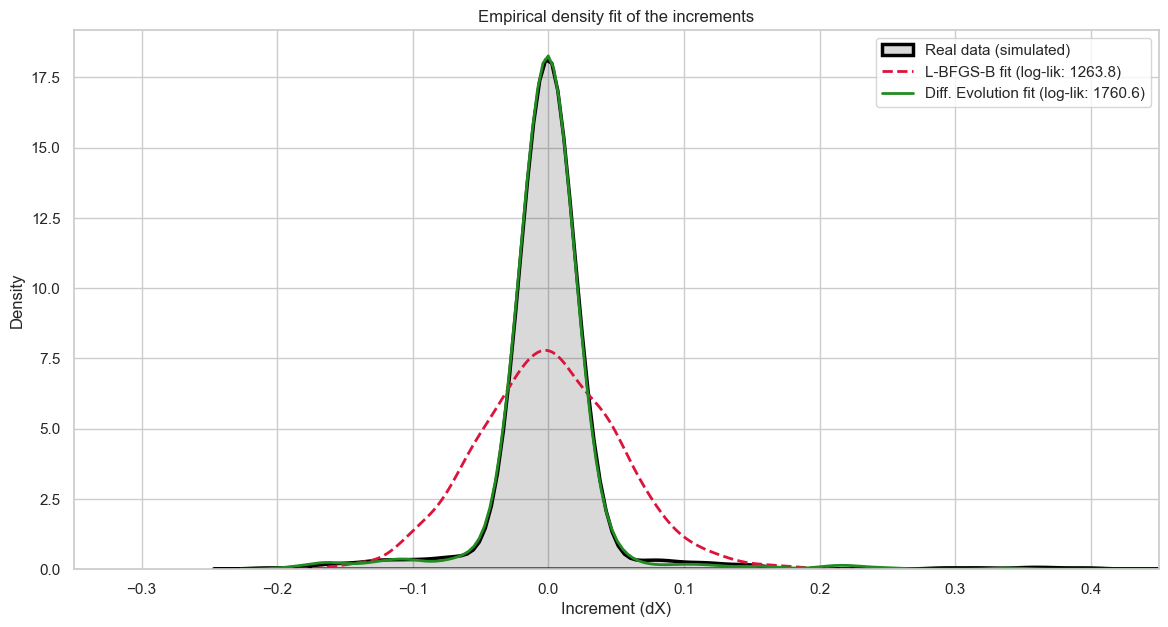

In [9]:
from jump_diffusion.models import JumpDiffusionModel

# Simulate synthetic samples to check goodness of fit
model_lbfgsb = JumpDiffusionModel(jump_distribution=SGEDJump(), **params_lbfgsb)
model_de = JumpDiffusionModel(jump_distribution=SGEDJump(), **params_de)

_, path_lbfgsb, _ = model_lbfgsb.simulate(T=T, n_steps=n_steps, x0=0.0, seed=100)
_, path_de, _ = model_de.simulate(T=T, n_steps=n_steps, x0=0.0, seed=100)

inc_lbfgsb = np.diff(path_lbfgsb)
inc_de = np.diff(path_de)

# Density comparison plot
plt.figure(figsize=(14, 7))
sns.kdeplot(increments, fill=True, color="black", alpha=0.15, linewidth=2.5, label="Real data (simulated)")
sns.kdeplot(inc_lbfgsb, color="crimson", linestyle="--", linewidth=2.0, label=f"L-BFGS-B fit (log-lik: {ll_lbfgsb:.1f})")
sns.kdeplot(inc_de, color="forestgreen", linestyle="-", linewidth=2.0, label=f"Diff. Evolution fit (log-lik: {ll_de:.1f})")

plt.title("Empirical density fit of the increments")
plt.xlabel("Increment (dX)")
plt.ylabel("Density")
plt.legend(frameon=True, facecolor="white")
plt.xlim(-0.35, 0.45)
plt.show()

## 6. Conclusions and discussion

This validation experiment clearly shows the performance contrast between local and global algorithms for estimating complex mixtures:

1. **Local stalling**: `L-BFGS-B` runs extremely fast (milliseconds) but often converges to wrong estimates of the jump-distribution parameters (`jump_nu` and `jump_xi`). This is because the mixture likelihood is multimodal and the starting point (moment guess) does not always fall in the basin of attraction of the global maximum.
2. **Global accuracy**: `differential_evolution` systematically explores the whole search space. Although slower (seconds), it recovers the true drift, volatility, probability and jump-skewness parameters with high precision. Its final log-likelihood is consistently higher than L-BFGS-B's.
3. **Recommended use**: in production or academic research settings (where estimation accuracy is critical for derivatives pricing or risk management), **Differential Evolution** is the recommended default estimation method for asymmetric, heavy-tailed jump mixtures.

## Standard errors via likelihood profiling

Once the parameters are estimated (preferably using Differential Evolution to secure the global optimum), we can compute standard errors and 95% confidence intervals using **likelihood profiling**.

This technique is far more robust than numerically computing the Hessian matrix (which is often unstable for complex mixtures).

Computing standard errors...


JUMP-DIFFUSION ESTIMATION RESULTS
Parameter          | Estimate   | Std Error  | 95% Conf. Interval    
--------------------------------------------------------------------
mu                 | -0.043463  | 0.153431   | [-0.3284, 0.2410]     
sigma              | 0.243996   | 0.007185   | [0.2314, 0.2582]      
jump_prob          | 0.096823   | 0.012410   | [0.0759, 0.1225]      
jump_loc           | 0.010452   | 0.013360   | [-0.0193, 0.0480]     
jump_scale         | 0.148939   | 0.014485   | [0.1253, 0.1938]      
jump_nu            | 1.743389   | 0.398049   | [1.1253, 2.7183]      
jump_xi            | 15.647106  | N/A        | [5.7894, 20.0000]     

Log-likelihood:         1760.59
AIC:                    -3507.19
BIC:                    -3474.79
Convergence:            True

DATA vs MODEL COMPARISON
------------------------------
Mean increment:
  Empirical:  0.000999
  Theoretical: -0.000172
Std deviation:
  Empirical:  0.048404
  Theoretical: 0.048827
Expected jumps: 73.2


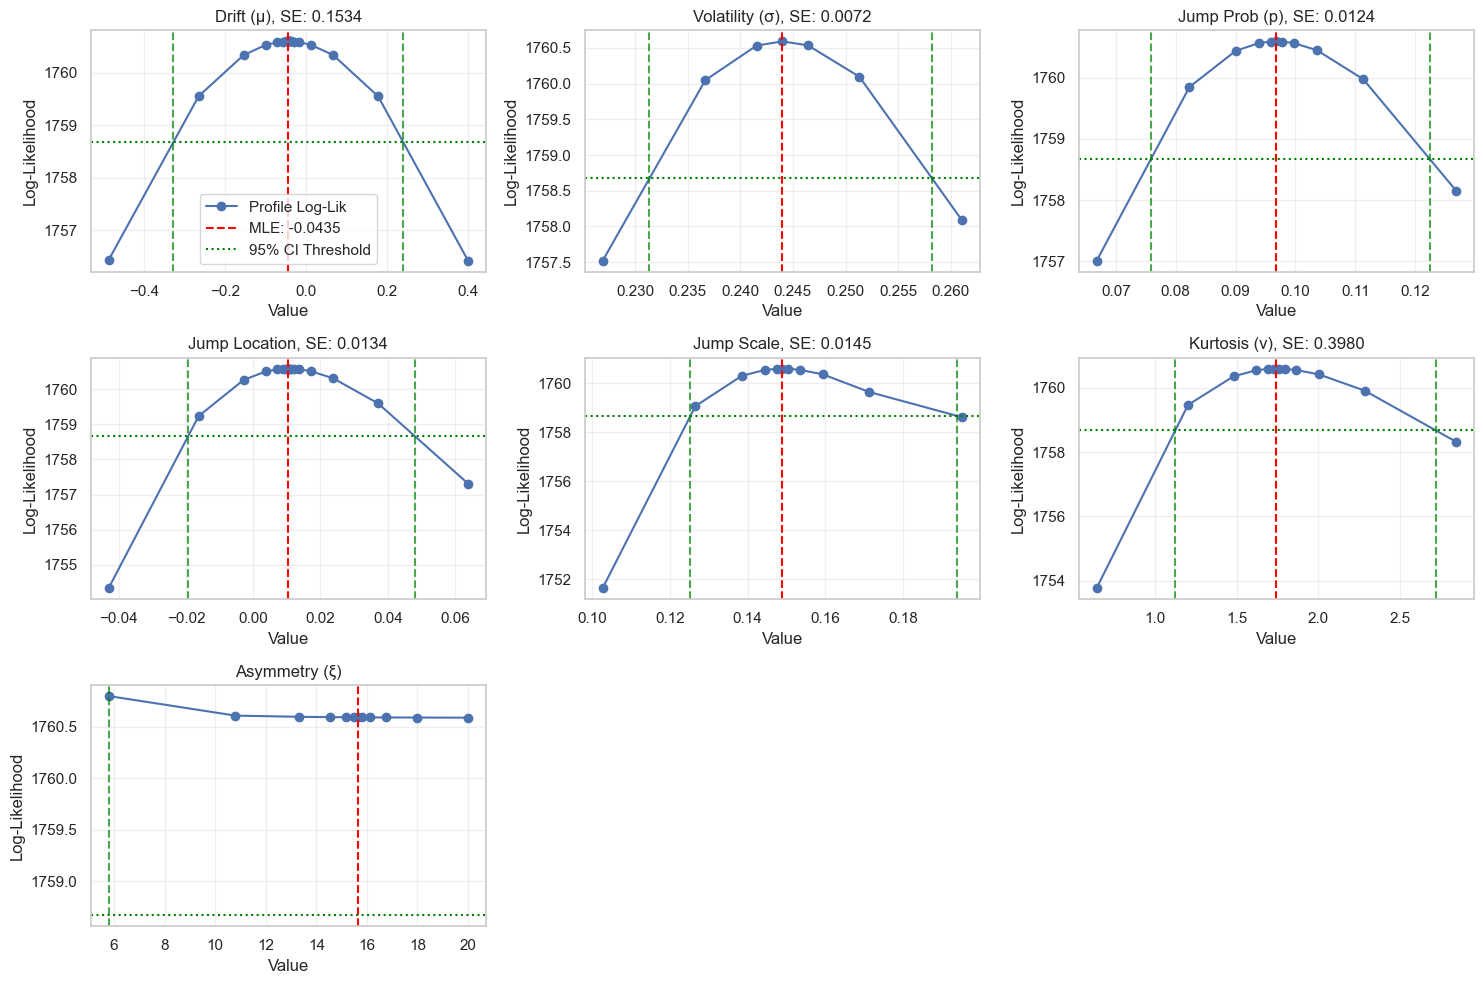

In [10]:
# Estimate standard errors by profiling (n_points=5 for speed here).
# Make sure you have run estimate() on the estimator first.
est = estimator_de

print("Computing standard errors...")
se_results = est.estimate_standard_errors(n_points=5, confidence_level=0.95)

# Print the diagnostics, now including the standard-error / interval table
est.diagnostics()

# Plot the profile likelihood curves for each parameter
est.plot_profiles()